### Variables auxiliares

In [1]:
import matplotlib.pyplot as plt 
import numpy as np 

import warnings
warnings.filterwarnings("ignore")


def reconstruct_map(patches, output_shape=(384, 416), patch_size=(32, 32)):
    """Efficiently reconstruct full map from patches.
    Input:
        - patches: tensor: (n,32,32)
    
    """
    grid_height = output_shape[0] // patch_size[0]
    grid_width = output_shape[1] // patch_size[1]
    return patches.reshape(grid_height, grid_width, *patch_size).transpose(0, 2, 1, 3).reshape(output_shape)

def split_patches_2d(tensor, patch_size=(32, 32)):
    # tensor: (384, 416) -> returns (num_patches, 32, 32)
    H, W = tensor.shape
    ph, pw = patch_size
    if H % ph or W % pw:
        raise ValueError("Las dimensiones deben ser múltiplos del patch_size")
    ny, nx = H // ph, W // pw
    patches = np.empty((ny * nx, ph, pw), dtype=tensor.dtype)
    k = 0
    for y in range(0, H, ph):
        for x in range(0, W, pw):
            patches[k] = tensor[y:y+ph, x:x+pw]
            k += 1
    return patches

def patches_to_maps_batched(patches, map_width=416):

    PH, PW = 32, 32
    NY, NX = 384 // PH, 416 // PW  # 12, 13
    PATCHES_PER_MAP = NY * NX      # 156
    # patches: (N,32,32,1) con N = 156 * B
    N, ph, pw, _ = patches.shape
    if ph!=PH or pw!=PW: raise ValueError("patch size distinto a 32x32")
    if N % PATCHES_PER_MAP != 0: raise ValueError("N no es múltiplo de 156")
    B = N // PATCHES_PER_MAP
    H, W = NY*PH, NX*PW  # 384, 416
    out = np.empty((B, H, W), dtype=patches.dtype)
    k = 0
    for b in range(B):
        m = np.empty((H, W), dtype=patches.dtype)
        for iy in range(NY):
            for ix in range(NX):
                y0, x0 = iy*PH, ix*PW
                m[y0:y0+PH, x0:x0+PW] = patches[k, :, :, 0]
                k += 1
        out[b] = m
    return out  # (B, 384, 416)

#### 1. Diferencia LR-HR topografía:

In [2]:
hgt_target_parches = np.load("parches/TR/RAW/hgt_target_raw_parches_TR.npy")
hgt_input_parches = np.load("parches/TR/RAW/hgt_input_raw_parches_TR.npy")

print("Dimensiones HGT target parches: ", hgt_target_parches.shape)
print("Dimensiones HGT input parches: ", hgt_input_parches.shape)

Dimensiones HGT target parches:  (284544, 32, 32, 1)
Dimensiones HGT input parches:  (284544, 32, 32, 1)


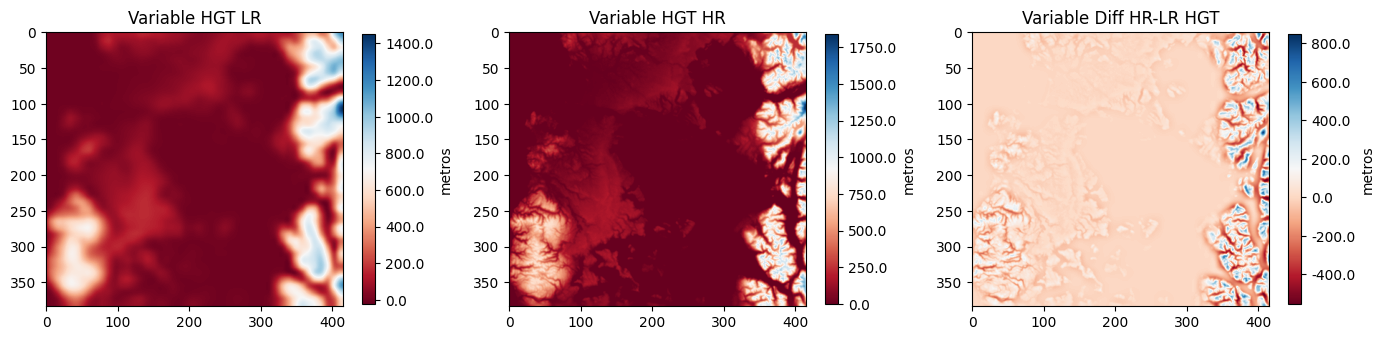

In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 8))

im1 = ax1.imshow(reconstruct_map(hgt_input_parches[:156])[::-1],  cmap='RdBu')
ax1.set_title('Variable HGT LR')
cbar1 = fig.colorbar(im1, ax=ax1,label='metros', format='%.1f', shrink=0.35)

im2 = ax2.imshow(reconstruct_map(hgt_target_parches[:156])[::-1],  cmap='RdBu')
ax2.set_title('Variable HGT HR')
cbar2 = fig.colorbar(im2, ax=ax2,label='metros',format='%.1f',shrink=0.35)

im3 = ax3.imshow(reconstruct_map(hgt_target_parches[:156] - hgt_input_parches[:156] )[::-1], cmap='RdBu')
ax3.set_title('Variable Diff HR-LR HGT')
cbar3 = fig.colorbar(im3, ax=ax3,label='metros',format='%.1f',shrink=0.35)

plt.tight_layout()
plt.show()

In [11]:
diff_hgt = hgt_target_parches - hgt_input_parches
np.save("parches/TR/RAW/diff_hgt_input_raw_parches_TR.npy", diff_hgt)
np.save("parches/VA/RAW/diff_hgt_input_raw_parches_VA.npy", diff_hgt[:114*156*8])
np.save("parches/TE/RAW/diff_hgt_input_raw_parches_TE.npy", diff_hgt[:114*156*8])

#### 2. Distancia a la costa: 

In [4]:
xland_target_parches = np.load("parches/TR/RAW/xland_target_raw_parches_TR.npy")
xland_maps = patches_to_maps_batched(xland_target_parches)  # (1824, 384, 416)
hgt_maps   = patches_to_maps_batched(hgt_target_parches)  # (1824, 384, 416)

In [49]:
from scipy.ndimage import convolve, binary_dilation, distance_transform_edt

def coastal_mask(xland, dilation_iters=5):
    """
    Calcula una máscara costera a partir de XLAND con 1=tierra y 2=agua.
    Retorna una máscara binaria donde 1 indica zonas costeras (bordes tierra-agua).
    """
    # Kernel Laplaciano para detectar bordes tierra-agua
    kernel = np.array([[0, 1, 0],
                       [1,-4, 1],
                       [0, 1, 0]])
    land = (xland == 1).astype(float)  # 1 en tierra, 0 en agua
    edges = convolve(land, kernel, mode='nearest')
    mask = (np.abs(edges) > 0)
    mask_dilated = binary_dilation(mask, iterations=dilation_iters)
    return mask_dilated.astype(np.uint8)

def distance_to_coast(xland, normalize=True):
    """
    Distancia de cada punto de AGUA (xland=2) a la costa (tierra xland=1).
    Retorna un array con distancias para puntos de agua y 0 para tierra.
    Si normalize=True, normaliza a [0,1] por el máximo.
    """
    land_mask = (xland == 1)
    # Distancia euclídea a tierra (en píxeles)
    dist = distance_transform_edt(~land_mask)
    # Mantener distancia solo en agua; 0 en tierra
    dist_water = np.where(xland == 2, dist, 0.0)
    if normalize:
        m = dist_water.max()
        if m > 0:
            dist_water = dist_water / m
    return dist_water

def transform_distance_exp(distance_map, beta=5.0):
    """
    Aplica una transformación exponencial decreciente para enfatizar distancias cortas.

    Parámetros:
    - distance_map: array 2D con distancias normalizadas en [0,1].
    - beta: parámetro que controla la rapidez de la caída (mayor beta = más énfasis en distancias cortas).

    Retorna:
    - transformed_map: array 2D con valores en [0,1], donde valores cercanos a la costa son cercanos a 1.
    """
    transformed_map = np.exp(-beta * distance_map)
    return transformed_map


In [50]:
distancia_costa = distance_to_coast(xland_maps[0])
mask_coast = coastal_mask(xland_maps[0])
distancia_costa_transformada = 1 - transform_distance_exp(distancia_costa)

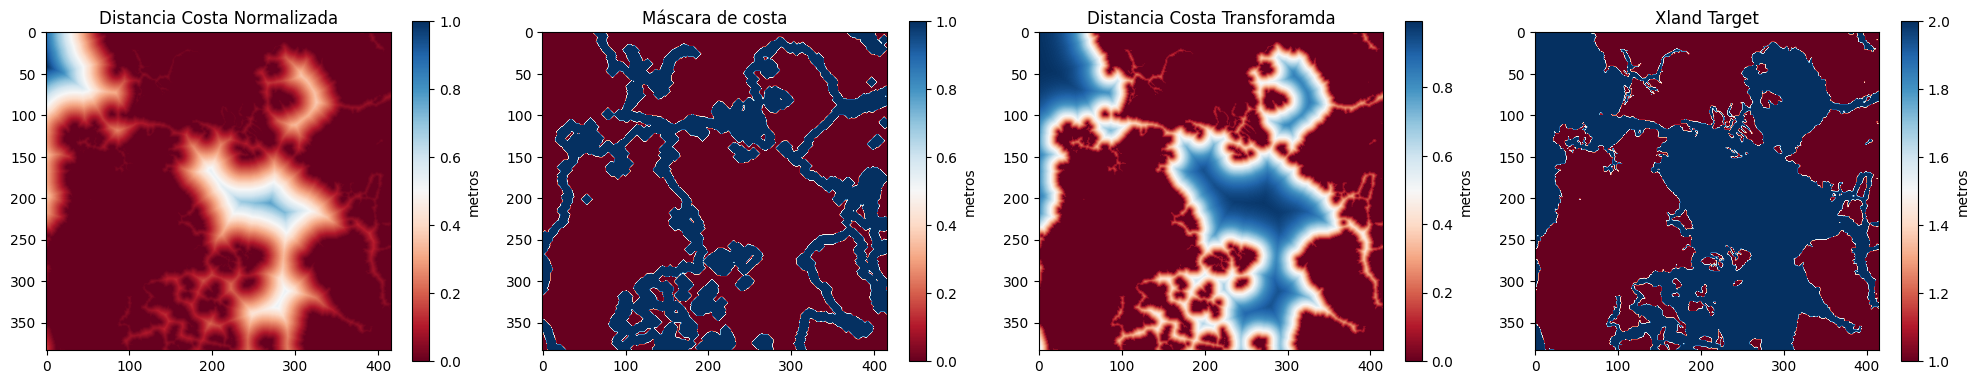

In [51]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 10))

im1 = ax1.imshow(distancia_costa[::-1],  cmap='RdBu')
ax1.set_title('Distancia Costa Normalizada')
cbar1 = fig.colorbar(im1, ax=ax1,label='metros', format='%.1f', shrink=0.35)

im2 = ax2.imshow(mask_coast[::-1],  cmap='RdBu')
ax2.set_title('Máscara de costa')
cbar2 = fig.colorbar(im2, ax=ax2,label='metros',format='%.1f',shrink=0.35)

im3 = ax3.imshow(distancia_costa_transformada[::-1], cmap='RdBu')
ax3.set_title('Distancia Costa Transforamda')
cbar3 = fig.colorbar(im3, ax=ax3,label='metros',format='%.1f',shrink=0.35)

im4 = ax4.imshow(xland_maps[0][::-1], cmap='RdBu')
ax4.set_title('Xland Target')
cbar4 = fig.colorbar(im4, ax=ax4,label='metros',format='%.1f',shrink=0.35)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.ndimage import distance_transform_edt, gaussian_filter
from skimage.morphology import binary_dilation, binary_opening, binary_closing, disk
from skimage.measure import label, regionprops

def coastal_products(xland, res_m, buffer_pix=3, open_rad=1, close_rad=2, min_area=20, L_km=15.0):
    land = (xland == 1)
    sea  = (xland == 2)

    # 1) Línea de costa explícita (frontera tierra–mar) + buffer
    se = disk(1)
    coast_line = (land & binary_dilation(sea, se)) | (sea & binary_dilation(land, se))
    coast_mask = binary_dilation(coast_line, disk(buffer_pix))

    # 2) Limpieza morfológica (opening/closing)
    if open_rad > 0:  coast_mask = binary_opening(coast_mask, disk(open_rad))
    if close_rad > 0: coast_mask = binary_closing(coast_mask, disk(close_rad))

    # 3) Quitar fragmentos pequeños
    lab = label(coast_mask)
    clean = np.zeros_like(coast_mask, dtype=bool)
    for r in regionprops(lab):
        if r.area >= min_area: clean[lab == r.label] = True
    coast_mask = clean

    # 4) Suavizado ligero y re-umbral (opcional pero útil)
    coast_mask = (gaussian_filter(coast_mask.astype(float), sigma=1.0) >= 0.5)

    # 5) Distancia a costa (para todo píxel) y proximidad
    dist_pix = distance_transform_edt(~coast_mask)
    dist_coast_km = dist_pix * (res_m / 1000.0)
    coastal_prox = np.exp(-dist_coast_km / L_km)

    return coast_mask.astype(np.uint8), dist_coast_km, coastal_prox

In [93]:
coast_mask, dist_coast_km, coastal_prox = coastal_products(xland_maps[0], res_m=333, buffer_pix=7.5) #mayor buffer, mayor robustez 

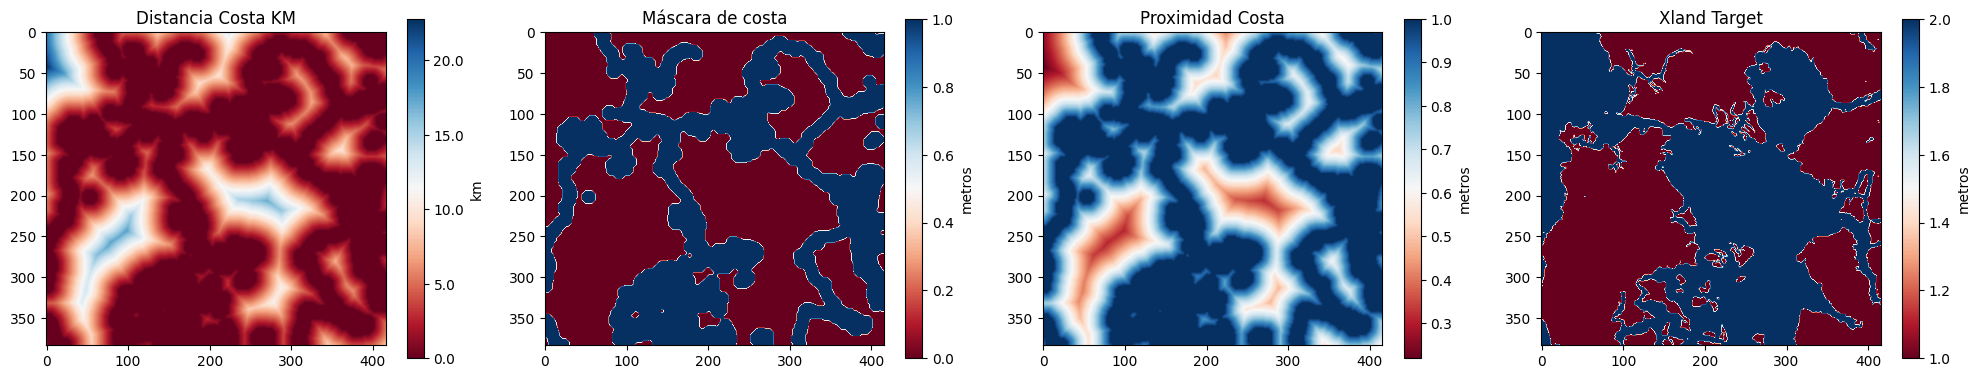

In [94]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 10))

im1 = ax1.imshow(dist_coast_km[::-1],  cmap='RdBu')
ax1.set_title('Distancia Costa KM')
cbar1 = fig.colorbar(im1, ax=ax1,label='km', format='%.1f', shrink=0.35)

im2 = ax2.imshow(coast_mask[::-1],  cmap='RdBu')
ax2.set_title('Máscara de costa')
cbar2 = fig.colorbar(im2, ax=ax2,label='metros',format='%.1f',shrink=0.35)

im3 = ax3.imshow(coastal_prox[::-1], cmap='RdBu')
ax3.set_title('Proximidad Costa')
cbar3 = fig.colorbar(im3, ax=ax3,label='metros',format='%.1f',shrink=0.35)

im4 = ax4.imshow(xland_maps[0][::-1], cmap='RdBu')
ax4.set_title('Xland Target')
cbar4 = fig.colorbar(im4, ax=ax4,label='metros',format='%.1f',shrink=0.35)

plt.tight_layout()
plt.show()

In [95]:
coast_mask_parches = split_patches_2d(coast_mask, patch_size=(32, 32))
coast_mask_parches = np.expand_dims( np.tile(coast_mask_parches,  (hgt_target_parches.shape[0] // 156, 1, 1)),  axis=-1)

In [97]:
np.save("parches/TR/RAW/coastmask_target_raw_parches_TR.npy", coast_mask_parches)
np.save("parches/VA/RAW/coastmask_target_raw_parches_VA.npy", coast_mask_parches[:114*156*8])
np.save("parches/TE/RAW/coastmask_target_raw_parches_TE.npy", coast_mask_parches[:114*156*8])

#### 3. Rugosidad de la superficie: 

ZNT en WRF es la longitud de rugosidad aerodinámica de la superficie. Resume el “tamaño efectivo” de las irregularidades del terreno (vegetación, edificaciones, relieve pequeño) que generan arrastre sobre el viento en la capa superficial y se usa en los esquemas de capa límite (perfil logarítmico/Monin–Obukhov).

- Valores cercanos a 0: superficies muy lisas con poco arrastre (mar abierto calmado, lagos, salares, superficies muy lisas).
- Valores cercanos a 1: superficies muy rugosas (bosque alto, áreas urbanas densas, vegetación muy alta), con fuerte fricción superficial.

In [83]:
rugosidad_znt = np.load("parches/ZNT/wrfout_d05_2017-05-13_00%3A00%3A00.npy")[0]
rugosidad_znt = np.expand_dims( np.tile(rugosidad_znt,  (hgt_target_parches.shape[0] // 156, 1, 1)),  axis=-1)

rugosidad_z0 = np.load("parches/Z0/wrfout_d05_2017-05-13_00%3A00%3A00.npy")[0]
rugosidad_z0 = np.expand_dims( np.tile(rugosidad_z0,  (hgt_target_parches.shape[0] // 156, 1, 1)),  axis=-1)

print("Dimensiones rugosidad znt: ", rugosidad_znt.shape)
print("Dimensiones rugosidad z0: ", rugosidad_z0.shape)

Dimensiones rugosidad znt:  (284544, 32, 32, 1)
Dimensiones rugosidad z0:  (284544, 32, 32, 1)


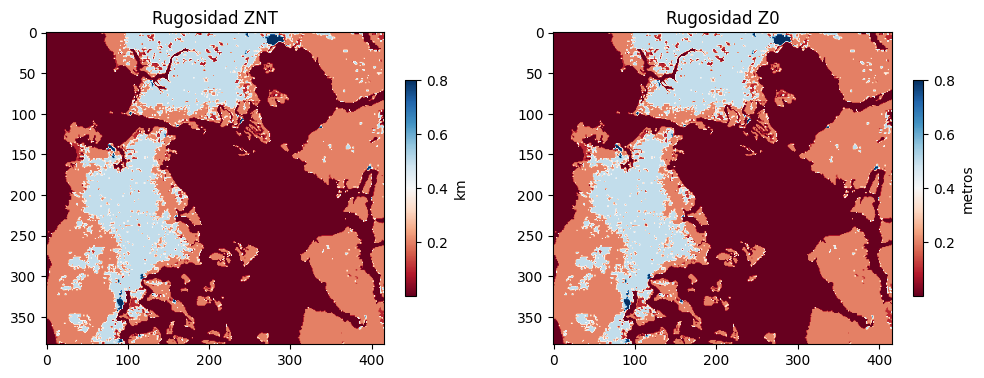

In [84]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

im1 = ax1.imshow(reconstruct_map(rugosidad_znt[:156])[::-1],  cmap='RdBu')
ax1.set_title('Rugosidad ZNT')
cbar1 = fig.colorbar(im1, ax=ax1,label='km', format='%.1f', shrink=0.35)

im2 = ax2.imshow(reconstruct_map(rugosidad_z0[:156])[::-1],  cmap='RdBu')
ax2.set_title('Rugosidad Z0')
cbar2 = fig.colorbar(im2, ax=ax2,label='metros',format='%.1f',shrink=0.35)

In [85]:
np.save("parches/TR/RAW/znt_target_raw_parches_TR.npy", rugosidad_znt)
np.save("parches/VA/RAW/znt_target_raw_parches_VA.npy", rugosidad_znt[:114*156*8])
np.save("parches/TE/RAW/znt_target_raw_parches_TE.npy", rugosidad_znt[:114*156*8])

#### 4. Cos y Sin de la dirección del viento

In [4]:
dir_tr = np.load("parches/TR/RAW/dir_input_raw_parches_TR.npy")
dir_va = np.load("parches/VA/RAW/dir_input_raw_parches_VA.npy")
dir_te = np.load("parches/TE/RAW/dir_input_raw_parches_TE.npy")

np.save("parches/TR/RAW/dir_cos_input_raw_parches_TR.npy", np.cos(np.deg2rad(dir_tr)))
np.save("parches/TR/RAW/dir_sin_input_raw_parches_TR.npy", np.sin(np.deg2rad(dir_tr)))

np.save("parches/VA/RAW/dir_cos_input_raw_parches_VA.npy", np.cos(np.deg2rad(dir_va)))
np.save("parches/VA/RAW/dir_sin_input_raw_parches_VA.npy", np.sin(np.deg2rad(dir_va)))

np.save("parches/TE/RAW/dir_cos_input_raw_parches_TE.npy", np.cos(np.deg2rad(dir_te)))
np.save("parches/TE/RAW/dir_sin_input_raw_parches_TE.npy", np.sin(np.deg2rad(dir_te)))